# Correct the Map: Africa's True Relative Size

This notebook shows how **Web Mercator** changes the way we see the size of continents. It compares Web Mercator with **Equal Earth**, places true-size outlines of Greenland and the contiguous United States over Africa, and explains what the results could mean for schools and mapmakers.

> Important: every flat world map changes something. Equal Earth is useful when comparing **area**. Mercator is still useful for navigation and detailed local maps.

## 1. Setup and reproducible map data

The first run downloads Natural Earth 1:110m country boundaries and caches the ZIP file in `data/`. Later runs use the local copy. If needed, install packages with:

```bash
pip install geopandas shapely pyproj matplotlib pandas
```

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from shapely.affinity import translate

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
COUNTRIES_ZIP = DATA_DIR / "ne_110m_admin_0_countries.zip"
DATA_URL = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)

if not COUNTRIES_ZIP.exists():
    print("Downloading Natural Earth country boundaries...")
    urlretrieve(DATA_URL, COUNTRIES_ZIP)

world = gpd.read_file(COUNTRIES_ZIP)
world = world.loc[world["CONTINENT"] != "Antarctica"].copy()
world = world.loc[~world.geometry.is_empty & world.geometry.notna()].copy()
print(f"Loaded {len(world)} country and territory features in {world.crs}.")


Loaded 176 country and territory features in EPSG:4326.


## 2. Compare the geographic, Mercator, and equal-area views

Many GIS applications display data directly in WGS 84 (`EPSG:4326`), creating the familiar rectangular longitude-and-latitude view below. EPSG:4326 stores locations in degrees. It is not an equal-area map, so sizes and shapes still change when it is shown on a flat screen.

Web Mercator (`EPSG:3857`) keeps local angles and directions useful, but it enlarges land more and more as it moves away from the equator. Africa crosses the equator, so it is enlarged much less than Greenland, Europe, and northern North America. Africa is not made smaller; other regions are made much larger.

Equal Earth (`EPSG:8857`) preserves relative area across the map and has a visually balanced outline, making it suitable for classroom wall maps and global thematic maps.

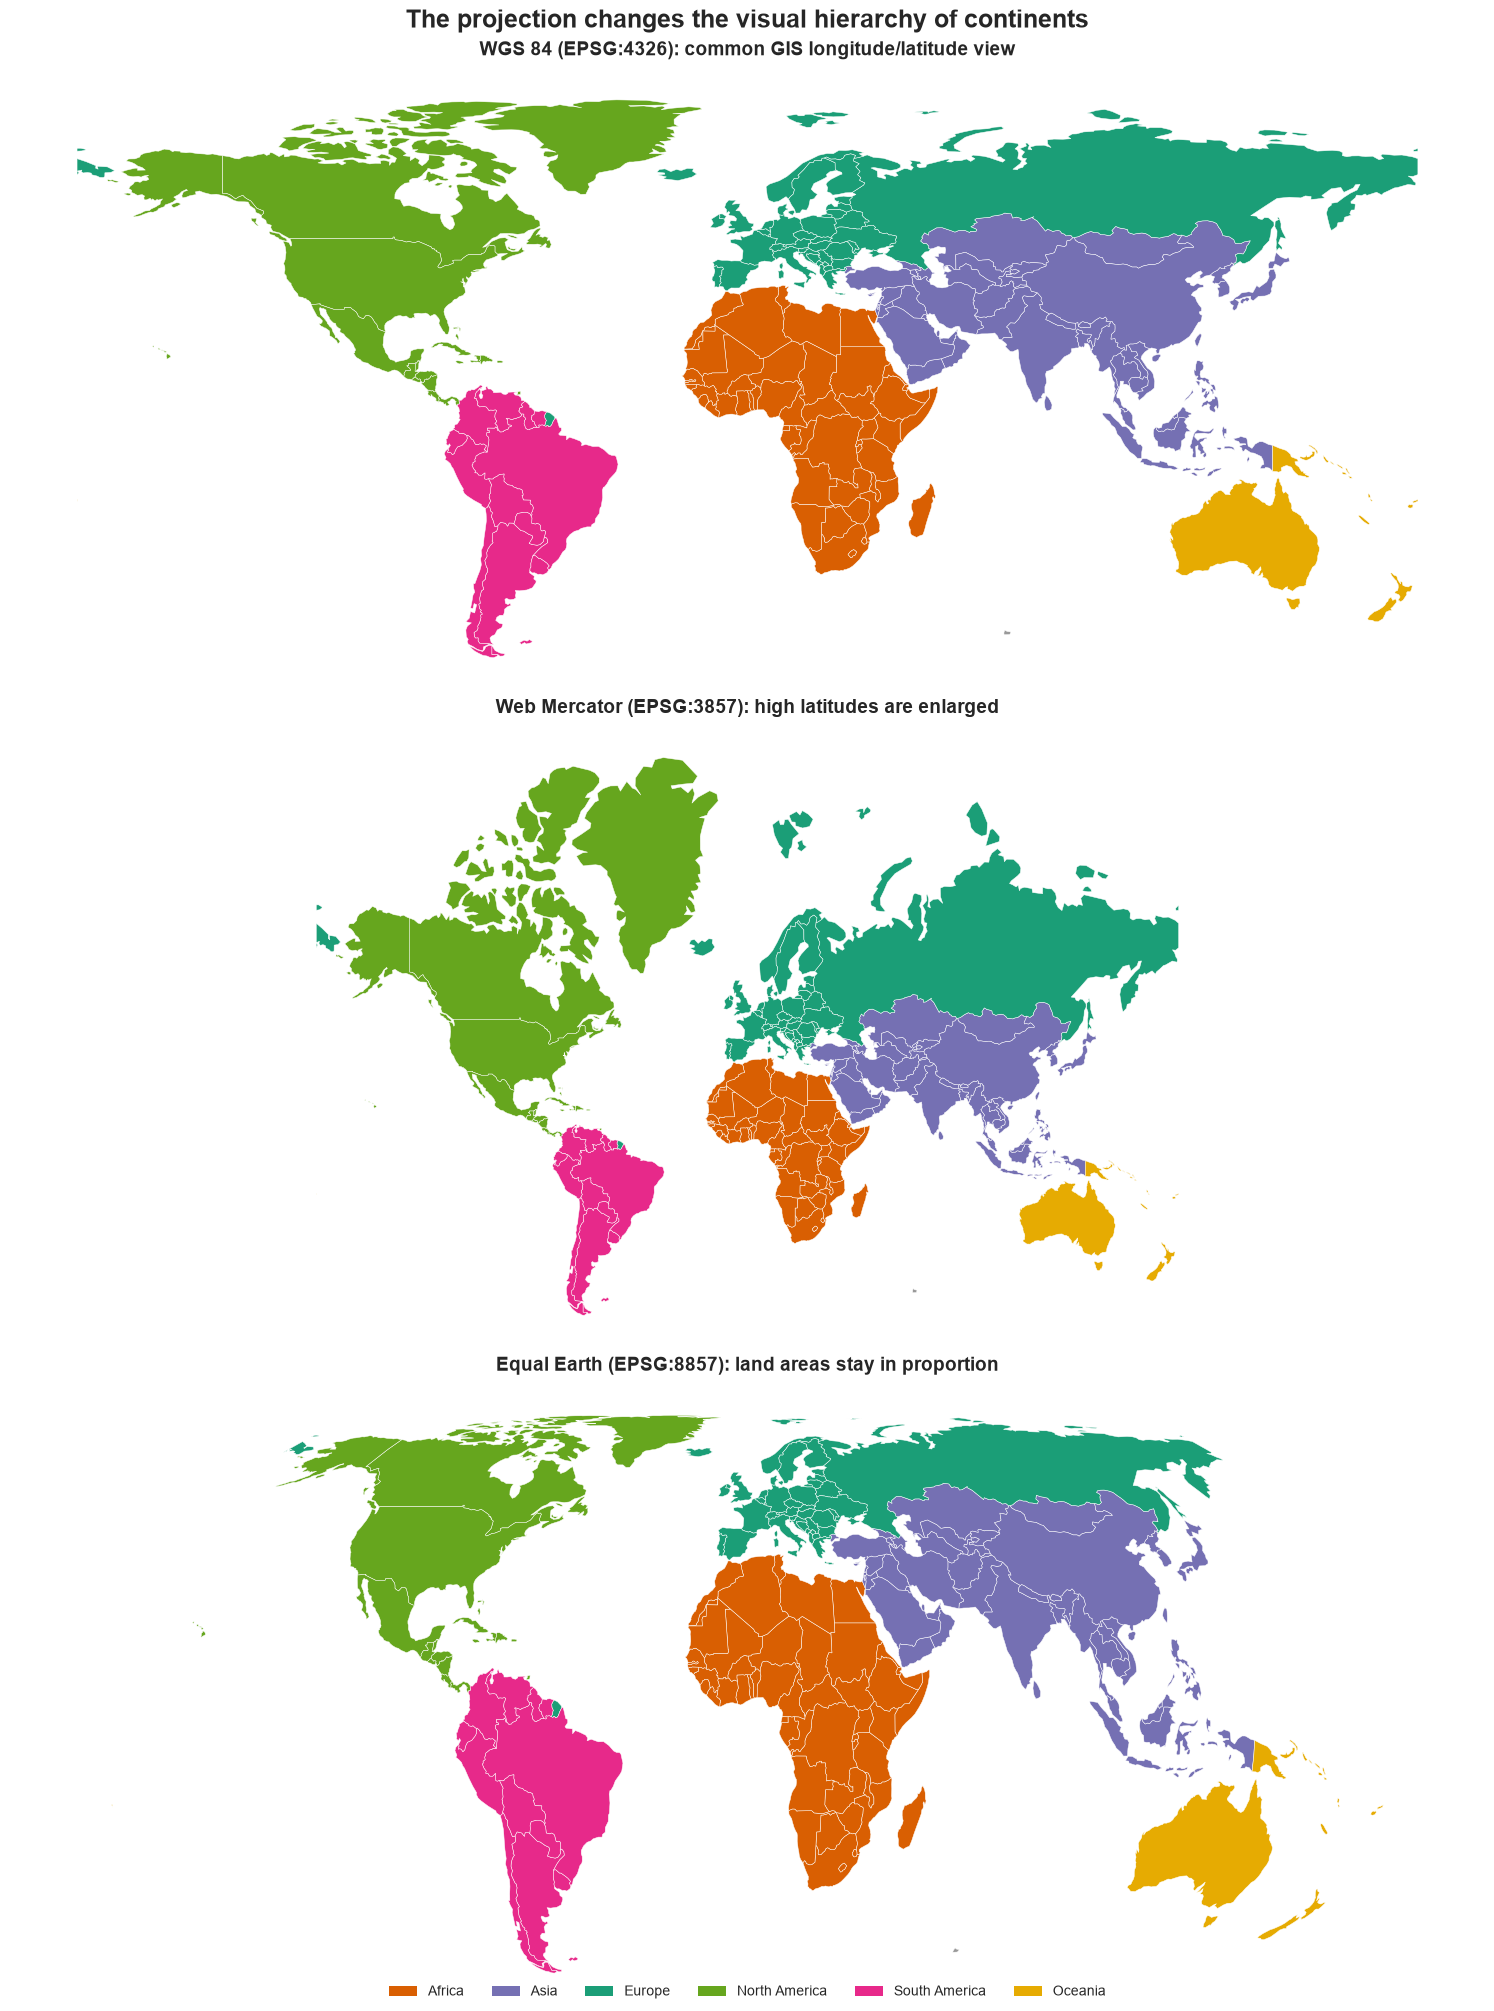

In [2]:
CRS_GEOGRAPHIC = "EPSG:4326"
CRS_WEB_MERCATOR = "EPSG:3857"
CRS_EQUAL_EARTH = "EPSG:8857"
CRS_EQUAL_AREA = "EPSG:6933"  # global equal-area CRS for measurements

world_geographic = world.to_crs(CRS_GEOGRAPHIC)
world_mercator = world.to_crs(CRS_WEB_MERCATOR)
world_equal_earth = world.to_crs(CRS_EQUAL_EARTH)

continent_colors = {
    "Africa": "#d95f02",
    "Asia": "#7570b3",
    "Europe": "#1b9e77",
    "North America": "#66a61e",
    "South America": "#e7298a",
    "Oceania": "#e6ab02",
    "Seven seas (open ocean)": "#999999",
}

def plot_world_by_continent(frame, ax, title):
    for continent, group in frame.groupby("CONTINENT"):
        group.plot(
            ax=ax, color=continent_colors.get(continent, "#bdbdbd"),
            edgecolor="white", linewidth=0.35
        )
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.set_axis_off()

fig, axes = plt.subplots(3, 1, figsize=(15, 20), constrained_layout=True)
plot_world_by_continent(
    world_geographic, axes[0],
    "WGS 84 (EPSG:4326): common GIS longitude/latitude view"
)
plot_world_by_continent(
    world_mercator, axes[1],
    "Web Mercator (EPSG:3857): high latitudes are enlarged"
)
plot_world_by_continent(
    world_equal_earth, axes[2],
    "Equal Earth (EPSG:8857): land areas stay in proportion"
)

legend = [
    Patch(facecolor=color, label=name)
    for name, color in continent_colors.items()
    if name != "Seven seas (open ocean)"
]
fig.legend(handles=legend, loc="lower center", ncol=6, frameon=False)
fig.suptitle(
    "The projection changes the visual hierarchy of continents",
    fontsize=18, weight="bold"
)
plt.show()


### A true-area continent layout

To give every continent a clearer shape, this view projects each one separately with a local **Lambert Azimuthal Equal Area** projection. Each local projection is centred near the middle of its continent, where shape change is lowest.

The projected pieces all use metres and the same scale. The code finds the centre of each projected continent and moves it to a chosen position using translation only: `x_new = x + dx` and `y_new = y + dy`. Translation changes location but does not change shape, width, height, or area. No scaling is applied.

The result combines clearer continental outlines with directly comparable land areas. It does **not remove all distortion**, and it is **not one continuous world projection**. The spaces, directions, and distances between continents are part of the layout and must not be measured. Russia is grouped with Asia so Europe and Asia appear as separate visual regions.

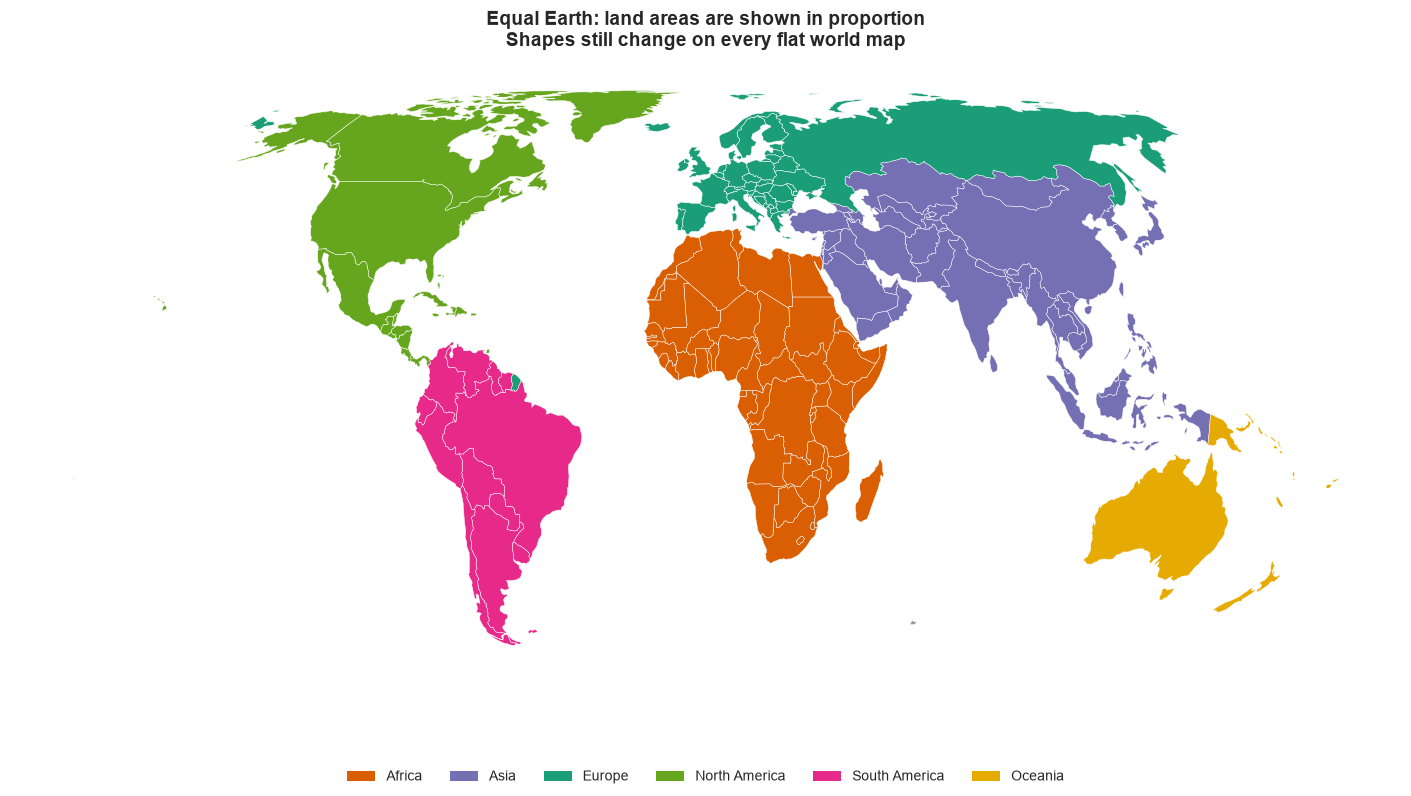

In [3]:
continent_world = world.copy()
continent_world.loc[
    continent_world["ADMIN"] == "Russia", "CONTINENT"
] = "Asia"

# A local equal-area projection keeps each continent's area while
# reducing the shape changes seen near the edge of a world map.
local_centers = {
    "Africa": (15, 0),
    "Europe": (15, 52),
    "Asia": (90, 35),
    "North America": (-105, 45),
    "South America": (-60, -15),
    "Oceania": (135, -25),
}
layout_positions = {
    "North America": (-10.3, 4.5),
    "Europe": (0, 6),
    "Asia": (10.3, 4),
    "South America": (-9, -5),
    "Africa": (0, -4),
    "Oceania": (10, -5),
}

fig, ax = plt.subplots(figsize=(15, 9), constrained_layout=True)
layout_order = [
    "North America", "Europe", "Asia",
    "South America", "Africa", "Oceania",
]
for continent in layout_order:
    center_lon, center_lat = local_centers[continent]
    local_crs = (
        f"+proj=laea +lat_0={center_lat} +lon_0={center_lon} "
        "+datum=WGS84 +units=m +no_defs"
    )
    group = continent_world.loc[
        continent_world["CONTINENT"] == continent
    ].to_crs(local_crs)
    minx, miny, maxx, maxy = group.total_bounds
    center_x = (minx + maxx) / 2
    center_y = (miny + maxy) / 2
    target_x, target_y = layout_positions[continent]
    group["geometry"] = group.geometry.translate(
        xoff=target_x * 1_000_000 - center_x,
        yoff=target_y * 1_000_000 - center_y,
    )
    group.plot(
        ax=ax, color=continent_colors[continent],
        edgecolor="white", linewidth=0.4,
    )

ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(
    "Continents at comparable true-area scale\n"
    "Projected separately and moved without resizing",
    fontsize=17, weight="bold", pad=14,
)
fig.legend(handles=legend, loc="lower center", ncol=6, frameon=False)
plt.show()


## 3. Measure the distortion instead of relying only on appearance

The table below computes land-polygon areas from the same generalized dataset. `EPSG:6933` supplies equal-area measurements; `EPSG:3857` supplies projected on-screen areas. The Natural Earth boundaries are generalized, so results are explanatory estimates rather than official national statistics.

In [4]:
world_equal_area = world.to_crs(CRS_EQUAL_AREA)

def union_for(frame, column, value):
    selected = frame.loc[frame[column] == value, "geometry"]
    if selected.empty:
        raise KeyError(f"No feature found where {column} == {value!r}")
    # Reprojection can expose tiny self-intersections in generalized borders.
    return selected.make_valid().union_all()

africa_ea = union_for(world_equal_area, "CONTINENT", "Africa")
greenland_ea = union_for(world_equal_area, "ADMIN", "Greenland")
usa_all_ea = union_for(
    world_equal_area, "ADMIN", "United States of America"
)

africa_web = union_for(world_mercator, "CONTINENT", "Africa")
greenland_web = union_for(world_mercator, "ADMIN", "Greenland")
usa_all_web = union_for(
    world_mercator, "ADMIN", "United States of America"
)

regions = {
    "Africa": (africa_ea, africa_web),
    "Greenland": (greenland_ea, greenland_web),
    "United States (all parts)": (usa_all_ea, usa_all_web),
}

rows = []
for name, (equal_geom, web_geom) in regions.items():
    true_area = equal_geom.area / 1_000_000
    web_area = web_geom.area / 1_000_000
    rows.append({
        "Region": name,
        "Equal-area estimate (million km²)": true_area / 1_000_000,
        "Web Mercator planar area (million km²)": web_area / 1_000_000,
        "Mercator inflation factor": web_area / true_area,
    })

area_table = pd.DataFrame(rows).set_index("Region")
display(area_table.round(2))

true_ratio = africa_ea.area / greenland_ea.area
mercator_ratio = africa_web.area / greenland_web.area
print(f"True-area relationship: Africa is about {true_ratio:.1f} times Greenland.")
print(
    f"On this Web Mercator model, Africa appears only "
    f"{mercator_ratio:.1f} times Greenland."
)


,Equal-area estimate (million km²),Web Mercator planar area (million km²),Mercator inflation factor
Region,,,
Africa,29.95,33.57,1.12
Greenland,2.21,36.29,16.44
United States (all parts),9.51,21.86,2.30


True-area relationship: Africa is about 13.6 times Greenland.
On this Web Mercator model, Africa appears only 0.9 times Greenland.


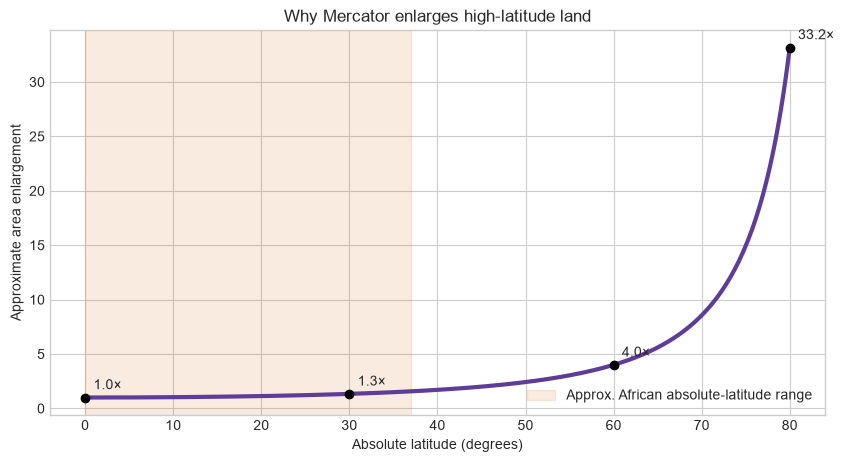

In [5]:
# In spherical Mercator, local area scale is approximately sec(latitude)^2.
latitudes = np.linspace(0, 80, 321)
area_scale = 1 / np.cos(np.deg2rad(latitudes)) ** 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(latitudes, area_scale, color="#5e3c99", linewidth=3)
ax.axvspan(
    0, 37, color="#d95f02", alpha=0.12,
    label="Approx. African absolute-latitude range"
)
for latitude in (0, 30, 60, 80):
    factor = 1 / np.cos(np.deg2rad(latitude)) ** 2
    ax.scatter(latitude, factor, color="black", zorder=3)
    ax.annotate(
        f"{factor:.1f}×", (latitude, factor), xytext=(6, 6),
        textcoords="offset points"
    )
ax.set(
    xlabel="Absolute latitude (degrees)",
    ylabel="Approximate area enlargement",
    title="Why Mercator enlarges high-latitude land",
)
ax.legend(frameon=False)
plt.show()


## 4. True-scale overlay on Africa

These overlays use the same equal-area CRS. `shapely.affinity.translate` changes only position—there is **no scaling**. To keep the comparison readable, Greenland and the contiguous-US polygon are shown in separate panels. The search function finds a translation that maximizes the portion overlapping Africa. This is a relative-footprint demonstration, not a claim that repeated copies have been mathematically packed inside Africa.

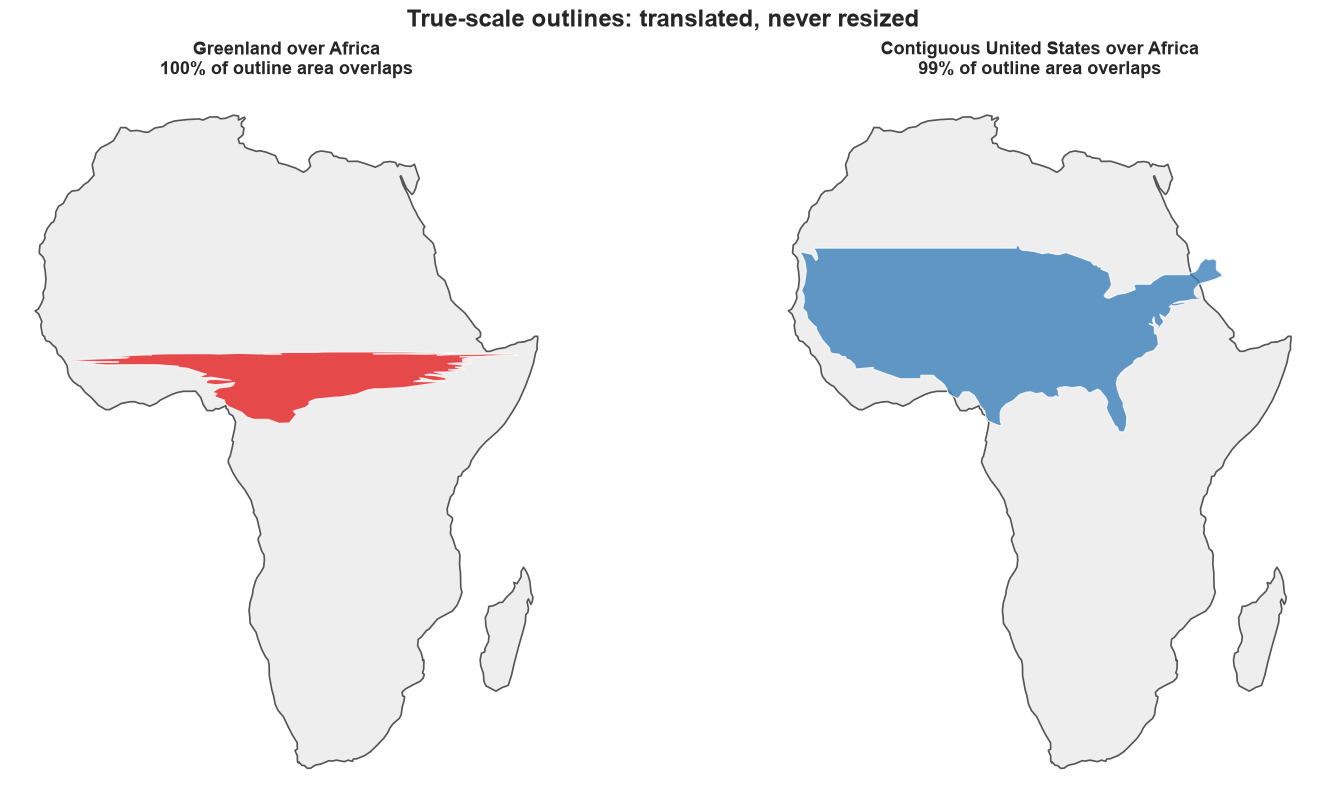

Africa / Greenland area ratio: 13.6×
Africa / contiguous-US area ratio: 3.8×


In [6]:
# Select the largest US polygon: the contiguous United States.
usa_parts = (
    list(usa_all_ea.geoms)
    if usa_all_ea.geom_type == "MultiPolygon"
    else [usa_all_ea]
)
usa_contiguous_ea = max(usa_parts, key=lambda geometry: geometry.area)

def best_translation(container, item, steps=45):
    """Translate item over a grid and maximize its area inside container."""
    minx, miny, maxx, maxy = container.bounds
    item_center = item.centroid
    xs = np.linspace(
        minx + 0.18 * (maxx - minx),
        maxx - 0.18 * (maxx - minx),
        steps,
    )
    ys = np.linspace(
        miny + 0.18 * (maxy - miny),
        maxy - 0.18 * (maxy - miny),
        steps,
    )
    best_geometry, best_fraction = None, -1.0
    for target_x in xs:
        for target_y in ys:
            candidate = translate(
                item,
                xoff=target_x - item_center.x,
                yoff=target_y - item_center.y,
            )
            fraction = container.intersection(candidate).area / item.area
            if fraction > best_fraction:
                best_geometry, best_fraction = candidate, fraction
    return best_geometry, best_fraction

greenland_shifted, greenland_overlap = best_translation(
    africa_ea, greenland_ea
)
usa_shifted, usa_overlap = best_translation(
    africa_ea, usa_contiguous_ea
)

overlays = [
    (greenland_shifted, greenland_overlap, "Greenland", "#e41a1c"),
    (
        usa_shifted, usa_overlap,
        "Contiguous United States", "#377eb8"
    ),
]

fig, axes = plt.subplots(
    1, 2, figsize=(15, 8), constrained_layout=True
)
for ax, (geometry, overlap, label, color) in zip(axes, overlays):
    gpd.GeoSeries([africa_ea], crs=CRS_EQUAL_AREA).plot(
        ax=ax, color="#eeeeee", edgecolor="#555555", linewidth=1.2
    )
    gpd.GeoSeries([geometry], crs=CRS_EQUAL_AREA).plot(
        ax=ax, color=color, edgecolor="white",
        linewidth=0.9, alpha=0.78
    )
    ax.set_title(
        f"{label} over Africa\n{overlap:.0%} of outline area overlaps",
        fontsize=13, weight="bold",
    )
    ax.set_axis_off()
fig.suptitle(
    "True-scale outlines: translated, never resized",
    fontsize=17, weight="bold",
)
plt.show()

print(
    f"Africa / Greenland area ratio: "
    f"{africa_ea.area / greenland_ea.area:.1f}×"
)
print(
    f"Africa / contiguous-US area ratio: "
    f"{africa_ea.area / usa_contiguous_ea.area:.1f}×"
)


## 5. Interpreting the social and sector effects

### Schools and education

- **Map literacy:** students can learn that every projection makes a trade-off instead of treating one flat map as objective reality.
- **Perception:** an equal-area classroom map stops northern regions from looking much larger than equatorial Africa. We should still avoid claiming that one map directly changes people's beliefs unless research proves it.
- **Transition work:** ministries, publishers, exam boards, wall-map suppliers, and digital learning platforms may need new artwork, teacher guidance, and assessment material.
- **Recommended practice:** use Equal Earth for global comparison, globes for the least mediated overview, and local projections chosen for the lesson or task.

### Geospatial, technology, and media

- **Keep Web Mercator where it works:** slippy-map tiles and interactive street basemaps can remain in `EPSG:3857`. Route engines normally calculate on geographic/network data; they should not infer distance or area from the displayed map.
- **Use equal-area CRS for area statistics:** choropleths, deforestation, agricultural coverage, population-density surfaces, and global comparisons should be calculated in a suitable equal-area CRS.
- **Separate storage, analysis, and display:** retain authoritative source coordinates, transform to an analysis CRS for measurement, then transform to the intended display CRS.
- **Practical work:** organizations may need new map files, updated websites, revised legends and scale bars, testing, and staff training.
- **Communication:** newsrooms and dashboards gain a less area-biased global overview, but users must be told that Equal Earth still distorts shapes, angles, and some distances.

## 6. Policy context and sources

The 2026 resolution is a **recommendation, not a law**. It encourages equal-area maps, including Equal Earth, when comparing size. It does not ban Mercator for navigation. The African Union had already adopted Equal Earth and asked Member States to update school curricula in February 2026.

Sources:

- [African Union Assembly Decision 959 (XXXIX), February 2026](https://au.int/sites/default/files/decisions/46188-Assembly_Decisions_E.pdf)
- [African Union communiqué on adoption of the Correct the Map resolution, 4 September 2026](https://www.au.int/en/pressreleases/20260904/communique-auc-chairperson-adoption-correct-map-resolution)
- [Natural Earth 1:110m cultural vectors](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/)
- [EPSG:8857 Equal Earth definition](https://epsg.io/8857)

### Final takeaway

Mercator is not wrong for every job, and Equal Earth is not perfect for every job. The simple lesson is to match the map to the task: **use an equal-area map to compare size, use a suitable local map for direction and shape, and always tell readers which projection was used.**